In [1]:
# 03_funnel
#
# 목적: 가입 -> 첫결제 -> 이용 -> 반복이용 -> 자동갱신 -> 재구독 단계별 전환 퍼널을 만든다.
#
# 단계 정의:
#   1. 가입: members_v3.csv 전체 유저
#   2. 첫 결제: transactions.csv에 거래 기록이 1건이라도 있는 유저
#   3. 이용: user_logs.csv에 청취 로그가 1건이라도 있는 유저
#   4. 반복 이용: 전체 기간 활동일수(full_active_days) >= 7일인 유저 (임의 임계값, 가정임을 명시)
#   5. 자동 갱신: 결제 이력 중 자동갱신(is_auto_renew=1) 거래가 1건이라도 있는 유저
#   6. 재구독: **라벨이 있는 코호트(2월 만료자, model_table_final.csv 대상)로 모집단이 축소됨** —
#      전체 회원 중 이 단계까지 온 유저 가운데 라벨이 있는 유저만 대상으로, 이탈하지 않은(is_churn=0) 비율
#      (원래는 2월+3월 만료 코호트를 풀링했으나, 3월 코호트는 raw 데이터에 3월 실적 원본이 없어
#       stale한 피처로 계산될 수밖에 없었고 이로 인해 라벨 충돌이 발생해 제거함 — plan 문서 참고)
#
# 1~5단계는 순차적 부분집합(AND)으로 계산하고, 6단계는 모집단이 달라짐을 그래프에 명시한다.
#
# 입력: data/raw/members_v3.csv, data/processed/features_transactions.csv,
#      data/processed/features_user_logs.csv, data/processed/model_table_final.csv
# 출력: 시각화만

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
SERIES_1 = "#2a78d6"
SERIES_2 = "#eb6834"
REPEAT_USAGE_THRESHOLD = 7

In [4]:
members = pd.read_csv(RAW_DIR / "members_v3.csv", usecols=["msno"])
transactions_feat = pd.read_csv(PROCESSED_DIR / "features_transactions.csv", usecols=["msno", "auto_renew_rate"])
user_logs_feat = pd.read_csv(PROCESSED_DIR / "features_user_logs.csv", usecols=["msno", "full_active_days"])
model_table = pd.read_csv(PROCESSED_DIR / "model_table_final.csv", usecols=["msno", "is_churn"])

print(f"members: {len(members):,} / transactions_feat: {len(transactions_feat):,} / "
      f"user_logs_feat: {len(user_logs_feat):,} / model_table(라벨 코호트): {model_table['msno'].nunique():,}명")

members: 6,769,473 / transactions_feat: 2,363,626 / user_logs_feat: 5,234,111 / model_table(라벨 코호트): 992,931명


In [5]:
all_members = set(members["msno"])
paid_set = set(transactions_feat["msno"])
used_set = set(user_logs_feat["msno"])
repeat_set = set(user_logs_feat.loc[user_logs_feat["full_active_days"] >= REPEAT_USAGE_THRESHOLD, "msno"])
auto_renew_set = set(transactions_feat.loc[transactions_feat["auto_renew_rate"] > 0, "msno"])

user_level_churn = model_table.groupby("msno")["is_churn"].max()  # 1 = 관측된 스냅샷 중 한 번이라도 이탈
labeled_msno = set(user_level_churn.index)
retained_msno = set(user_level_churn[user_level_churn == 0].index)

stage1 = all_members
stage2 = stage1 & paid_set
stage3 = stage2 & used_set
stage4 = stage3 & repeat_set
stage5 = stage4 & auto_renew_set
stage6_denominator = stage5 & labeled_msno   # 모집단 축소 지점
stage6 = stage6_denominator & retained_msno

funnel = pd.DataFrame({
    "stage": ["1. 가입", "2. 첫 결제", "3. 이용", "4. 반복 이용", "5. 자동 갱신", "6. 재구독\n(라벨 코호트 한정)"],
    "count": [len(stage1), len(stage2), len(stage3), len(stage4), len(stage5), len(stage6)],
    "denominator": [None, len(stage1), len(stage2), len(stage3), len(stage4), len(stage6_denominator)],
})
funnel["stage_conversion_pct"] = (funnel["count"] / funnel["denominator"] * 100).round(1)
funnel["overall_pct"] = (funnel["count"] / len(stage1) * 100).round(1)
funnel

,stage,count,denominator,stage_conversion_pct,overall_pct
0,1. 가입,6769473,NaN,NaN,100.0
1,2. 첫 결제,1931003,6769473.0,28.5,28.5
2,3. 이용,1878148,1931003.0,97.3,27.7
3,4. 반복 이용,1552512,1878148.0,82.7,22.9
4,5. 자동 갱신,991567,1552512.0,63.9,14.6
5,6. 재구독\n(라벨 코호트 한정),711466,735707.0,96.7,10.5


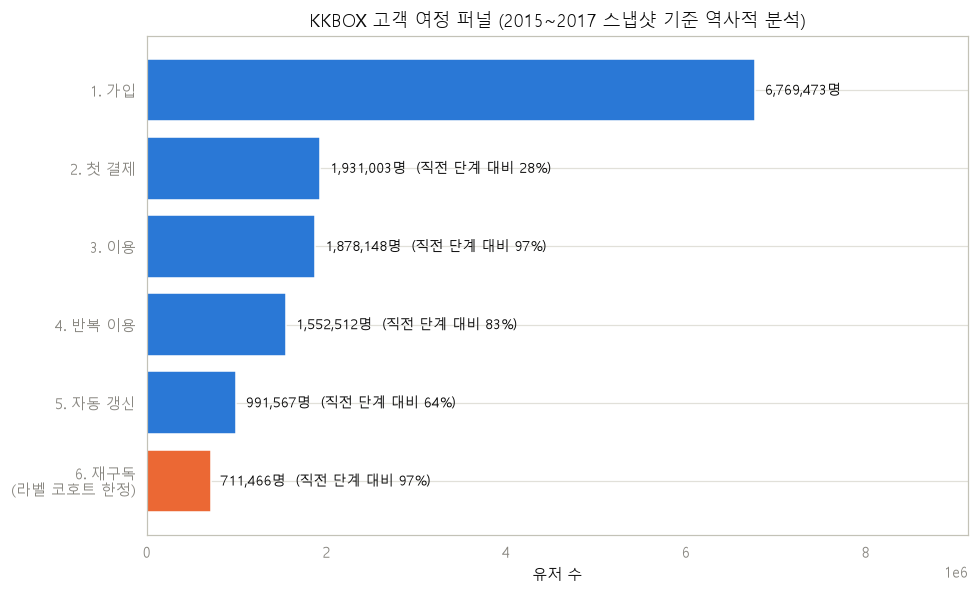

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [SERIES_1] * 5 + [SERIES_2]  # 마지막 단계는 모집단이 달라서 색으로 구분
bars = ax.barh(funnel["stage"], funnel["count"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("유저 수")
ax.set_title("KKBOX 고객 여정 퍼널 (2015~2017 스냅샷 기준 역사적 분석)")

for bar, row in zip(bars, funnel.itertuples()):
    label = f"{row.count:,}명"
    if row.stage_conversion_pct == row.stage_conversion_pct:  # not NaN
        label += f"  (직전 단계 대비 {row.stage_conversion_pct:.0f}%)"
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, "  " + label, va="center", fontsize=9)

ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_xlim(0, funnel["count"].max() * 1.35)
plt.tight_layout()
plt.show()

In [7]:
# ------------------------------------------------------------------
# 해석 시 주의할 점
# 1. 1~5단계는 전체 회원(676만명) 기준 순차 부분집합. 6단계(재구독)는 라벨이 있는
#    2월 만료 코호트로 모집단이 축소됨(주황색 막대로 구분 표시) -- 다른 단계와 직접
#    비교 시 이 모집단 차이를 반드시 함께 언급해야 한다.
# 2. "반복 이용" 임계값(7일)은 임의로 정한 기준이며, 다른 기준을 쓰면 수치가 달라진다.
# 3. 가장 전환율이 낮은 단계가 어디인지가 "어디에 개선 여지가 있는가"에 대한 1차 힌트가 되지만,
#    상관관계 수준의 관찰이며 인과관계를 증명하는 것은 아니다.
# ------------------------------------------------------------------
print("퍼널 분석 완료 (위 주석의 해석 주의사항 참고)")

퍼널 분석 완료 (위 주석의 해석 주의사항 참고)
